## Middleware

In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter,CharacterTextSplitter
from langchain_community.document_loaders import TextLoader,PyMuPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma,FAISS
import fitz  

#utility
import numpy as np
from typing import List,Dict,Any
from sentence_transformers import SentenceTransformer

from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.runnables import (RunnablePassthrough,RunnableMap)
from langchain_core.output_parsers import StrOutputParser
import os
import numpy as np
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_core.documents import Document

from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains.retrieval import create_retrieval_chain
from langchain_classic.document_loaders import WikipediaLoader
from PIL import Image
import torch
from transformers import CLIPProcessor,CLIPModel
import base64
import io
from langchain.messages import SystemMessage,HumanMessage,AIMessage
from pydantic import BaseModel,Field
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware,HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage,SystemMessage
from langchain.tools import tool

In [5]:
## Step 4: LLM and prompt
import os
from dotenv import load_dotenv

load_dotenv()
API=os.getenv("OPENAI_API_KEY")
llm=init_chat_model(model="groq:llama-3.3-70b-versatile",api_key=API)
response=llm.invoke("Why do parrots talk?")
response

AIMessage(content='Parrots are known for their remarkable ability to mimic human speech and other sounds, but why do they do it? The answer lies in their evolution, social behavior, and communication needs.\n\n**Evolutionary advantages:**\n\n1. **Mimicry as a survival strategy**: In the wild, parrots have learned to mimic the calls of other birds, animals, and even predators to warn their flock of potential threats or to blend in with their surroundings.\n2. **Territorial defense**: By mimicking the calls of other birds, parrots can establish their territory and deter potential competitors.\n3. **Attracting a mate**: Male parrots may use their vocal mimicry to attract females, showcasing their intelligence and creativity.\n\n**Social behavior:**\n\n1. **Communication with flock members**: Parrots live in social groups, and vocalization is a key way for them to communicate with each other. They use a variety of calls to convey information about food, predators, and social interactions.\

In [6]:
os.environ["GROQ_API_KEY"] =os.getenv("OPENAI_API_KEY")

## Summarizarion Middleware

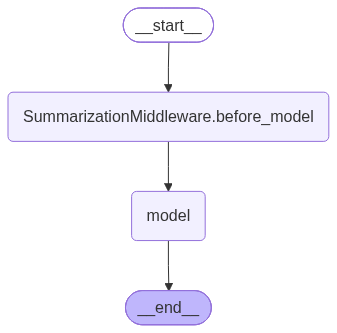

In [7]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage,SystemMessage
agent=create_agent(
    model="groq:llama-3.3-70b-versatile",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:llama-3.3-70b-versatile",
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
 
)
agent

## Run with thread id

In [8]:
config={
    'configurable':{"thread_id":"test-1"}
}

In [9]:
question=[
    "What is 2+2",
    'What is 10*5',
    "What is 100/4",
    "Whats is 15-7",
    "What is 3*3",
    "What is 4*4*4,"

]
for q in question:
    print("-"*100)
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages:{response}")
    print(f"Messages:->{len(response['messages'])}")
    print(f"Answer: {response['messages'][-1].content}")
print("-"*100)
    

----------------------------------------------------------------------------------------------------
Messages:{'messages': [HumanMessage(content='What is 2+2', additional_kwargs={}, response_metadata={}, id='79d38163-1eb0-48ad-8b19-670b2bfd176d'), AIMessage(content='2 + 2 = 4', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 41, 'total_tokens': 49, 'completion_time': 0.01058259, 'completion_tokens_details': None, 'prompt_time': 0.001971725, 'prompt_tokens_details': None, 'queue_time': 0.162414053, 'total_time': 0.012554315}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9424-dcfd-73b2-96d6-c165fc22f54a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 8, 'total_tokens': 49})]}
Messages:->2
Answer: 2 + 2 = 4
---------------------------------------

## Token Size

In [10]:
from langchain.tools import tool

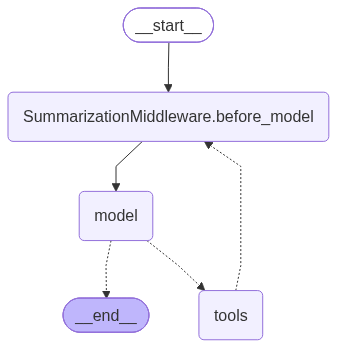

In [11]:
@tool
def search_hotels(city:str)->str:
    """Search hotels - return long responses to use more tokens"""
    return f""" Hotels in {city}:
    1.Grand hotel -5 star,$350/night,spa,pool 
    2.City Inn- 4 star,$100/night,buisnesscenter"""

agents=create_agent(
    model="groq:llama-3.3-70b-versatile",
    checkpointer=InMemorySaver(),
    tools=[search_hotels],
    middleware=[
        SummarizationMiddleware(
            model="groq:llama-3.3-70b-versatile",
            trigger=("tokens",550),
            keep=("tokens",200)
        )
    ]
 
)
agents

In [12]:
def count(messages):
    ttc=sum(len(str(m.content)) for m in messages)
    return ttc//4

In [13]:
ct=["Morena","Paris","london","Tokyo"]
for c in ct:
    print("-"*50)
    response = agents.invoke(
        {"messages": [HumanMessage(content=f"find hotels in  {c}")]},
        config
    )
    tokens=count(response['messages'])

 
    print(f"Response: {response}")
    print(f"Number of messages: {len(response['messages'])}")
    print(f"Answer: {response['messages'][-1].content}")
    print(tokens)

   
print("-"*50)



--------------------------------------------------
Response: {'messages': [HumanMessage(content='find hotels in  Morena', additional_kwargs={}, response_metadata={}, id='f22e1917-c643-4d7b-ab98-4baca63c364a'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'zfsv99s9a', 'function': {'arguments': '{"city":"Morena"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 228, 'total_tokens': 244, 'completion_time': 0.038905768, 'completion_tokens_details': None, 'prompt_time': 0.011348131, 'prompt_tokens_details': None, 'queue_time': 0.162273154, 'total_time': 0.050253899}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9424-f064-72e2-8480-75810ed48e61-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Morena'}, 'id': 'zfsv99s9a', 'type': 'to

## Human in the Loop Middleware
